# Análise de Jogos Steam — Pipeline Completo

**Grupo 6 | PISI 3 | 2026.1**

Este notebook cobre o pipeline completo de análise: carregamento e limpeza dos dados, análise exploratória (EDA), modelagem supervisionada (classificação de sucesso comercial) e clusterização (KMeans).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =============================================================
# CONFIGURAÇÃO GERAL — Instalações, Imports e Download dos Dados
# =============================================================

# --- Instalações ---
!pip install -U gdown -q
!pip install pyarrow fastparquet -q
!pip install imbalanced-learn -q
!pip install shap -q

# --- Bibliotecas padrão ---
import os
import json
import warnings
import gc

# --- Ciência de dados ---
import numpy as np
import pandas as pd
from datetime import datetime
from scipy.stats import gaussian_kde

# --- Visualização ---
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import plotly.graph_objects as go

# --- Machine Learning: pré-processamento ---
import pyarrow
import gdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

# --- Machine Learning: modelos ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- Machine Learning: avaliação ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, silhouette_score
)

# --- Interpretabilidade ---
import shap
import joblib

warnings.filterwarnings('ignore')
shap.initjs()

print(f"✓ SHAP versão: {shap.__version__}")
print("✓ Todas as bibliotecas importadas com sucesso.")

# --- Download dos datasets do Google Drive ---
file_ids = {
    'games.csv':           '1H1SWzyxO3cwCk1W-CJ5CSn1bkNQPUafp',
    'recommendations.csv': '1D6Q_239NtzT3M_A7sD6x1r4XB0_1ypMX',
    'games_metadata.json': '1no_OD3ljg7FUrVsXjaurjti3DNprxrMK',
    'steam_reviews.csv':   '1j3lcuki7AfCx_at0baAtaYUVLxsAfYtD'
}

for filename, file_id in file_ids.items():
    if not os.path.exists(filename):
        print(f"Baixando {filename}...")
        !gdown {file_id} -O {filename}
    else:
        print(f"✓ {filename} já presente no ambiente.")


✓ SHAP versão: 0.52.0
✓ Todas as bibliotecas importadas com sucesso.
Baixando games.csv...
Downloading...
From: https://drive.google.com/uc?id=1H1SWzyxO3cwCk1W-CJ5CSn1bkNQPUafp
To: /content/games.csv
100% 4.86M/4.86M [00:00<00:00, 31.6MB/s]
Baixando recommendations.csv...
Downloading...
From (original): https://drive.google.com/uc?id=1D6Q_239NtzT3M_A7sD6x1r4XB0_1ypMX
From (redirected): https://drive.google.com/uc?id=1D6Q_239NtzT3M_A7sD6x1r4XB0_1ypMX&confirm=t&uuid=c4fca42b-7c9b-4f83-8a5a-09f5c2449d15
To: /content/recommendations.csv
100% 2.02G/2.02G [00:34<00:00, 58.2MB/s]
Baixando games_metadata.json...
Downloading...
From: https://drive.google.com/uc?id=1no_OD3ljg7FUrVsXjaurjti3DNprxrMK
To: /content/games_metadata.json
100% 17.5M/17.5M [00:00<00:00, 61.3MB/s]
Baixando steam_reviews.csv...
Downloading...
From (original): https://drive.google.com/uc?id=1j3lcuki7AfCx_at0baAtaYUVLxsAfYtD
From (redirected): https://drive.google.com/uc?id=1j3lcuki7AfCx_at0baAtaYUVLxsAfYtD&confirm=t&uuid=ef

---
## 1. Carregamento e Limpeza dos Dados

In [ ]:
df_games = pd.read_csv('games.csv')
df_games.columns = df_games.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)
print(f"O dataset possui {df_games.shape[0]} jogos e {df_games.shape[1]} colunas.")
display(df_games.head())

print("\nResumo técnico das colunas:")
df_games.info()

O dataset possui 50872 jogos e 13 colunas.


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True



Resumo técnico das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  object 
 2   date_release    50872 non-null  object 
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  object 
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), object(3)
memory usage: 3.7+ MB


In [ ]:
# Limpeza de dados após a leitura: Camada extra de tratamento
# 1. Convertendo a coluna de data para datatime
df_games['date_release'] = pd.to_datetime(df_games['date_release'], errors='coerce')

# 2. Garantindo que a coluna de título seja estritamente texto (string)
df_games['title'] = df_games['title'].astype(str)

# 3. Otimização: 'rating' tem valores que se repetem muito ('Very Positive', 'Mixed'). A transformação gera uma economia na memoria do parquet.
df_games['rating'] = df_games['rating'].astype('category')

---
## 2. Análise Exploratória (EDA)

In [ ]:
# EDA — Qualidade vs. Popularidade
# Criando um gráfico de dispersão para ver a relação entre popularidade e nota

df_plot = df_games[df_games['user_reviews'] > 100] #Filtando jogos com mais de 100 reviews para evitar 'ruído' de jogos irrelevantes

fig = px.scatter(
    df_plot,
    x="positive_ratio",
    y="user_reviews",
    color="rating",
    log_y=True, # Escala logarítmica pois alguns jogos têm milhões de reviews e outros milhares
    title="Relação entre Porcentagem de Avaliações Positivas e Volume de Reviews",
    labels={'positive_ratio': 'Avaliações Positivas (%)', 'user_reviews': 'Total de Reviews (Log)'},
    hover_name="title",
    template="plotly_white"
)

fig.show()

In [ ]:
# EDA — Impacto do Preço no Sucesso

# Criando uma métrica de 'Faturamento Estimado' simplificada (Preço * Reviews)
# Usamos reviews como proxy de vendas (Método Boxleiter simplificado)

df_games['est_revenue_proxy'] = df_games['price_final'] * df_games['user_reviews']

# Filtrando apenas para visualização (jogos que custam algo e têm reviews)
df_price_analysis = df_games[(df_games['price_final'] > 0) & (df_games['user_reviews'] > 100)]

fig_price = px.scatter(
    df_price_analysis,
    x="price_final",
    y="est_revenue_proxy",
    size="positive_ratio", # O tamanho da bolha indica a nota
    color="steam_deck",    # Cor indica se roda no Steam Deck
    log_y=True,
    hover_name="title",
    title="Preço Final vs. Estimativa de Receita (Proxy)",
    labels={'price_final': 'Preço (USD)', 'est_revenue_proxy': 'Receita Estimada (Log)'},
    template="plotly_white"
)

fig_price.show()

In [ ]:
# Engajamento (Horas Jogadas) — Processamento e EDA

# Lemos apenas ID do jogo e horas para poupar a memória
df_recom = pd.read_csv('recommendations.csv', usecols=['app_id', 'hours'])

# Calculamos a média e a mediana de horas jogadas para cada app_id
df_engagement = df_recom.groupby('app_id').agg(
    avg_hours=('hours', 'mean'),
    median_hours=('hours', 'median')
).reset_index()

# Deletamos a base pesada de 12 milhões de linhas e forçamos a limpeza
del df_recom
gc.collect()

# Remove columns from df_games that might cause a MergeError if they exist from a previous run.
# This ensures that 'avg_hours' and 'median_hours' are added cleanly from df_engagement.
cols_to_remove_before_merge = [
    'avg_hours', 'median_hours',      # Direct conflicting columns
    'avg_hours_x', 'median_hours_x',  # Suffixed columns from previous failed merges
    'avg_hours_y', 'median_hours_y'   # Suffixed columns from previous failed merges
]
for col in cols_to_remove_before_merge:
    if col in df_games.columns:
        df_games = df_games.drop(columns=[col])

df_games = pd.merge(df_games, df_engagement, on='app_id', how='left')

# Preenche jogos sem dados de horas com 0 para não quebrar o gráfico
df_games['avg_hours'] = df_games['avg_hours'].fillna(0)

# 1. Preparação e filtragem rigorosa dos dados originais
df_plot_eng = df_games[(df_games['user_reviews'] > 100) & (df_games['avg_hours'] > 0) & (df_games['est_revenue_proxy'] > 0)].copy()

# 2. Cálculo Estatístico da Densidade Suave (KDE) em espaço logarítmico
# Isso impede que os dados fiquem espremidos e distribui a densidade por todo o plano
log_x = np.log10(df_plot_eng['avg_hours'])
log_y = np.log10(df_plot_eng['est_revenue_proxy'])
kde_values = np.vstack([log_x, log_y])
df_plot_eng['real_density'] = gaussian_kde(kde_values)(kde_values)

# =====================================================================
# GRÁFICO PRINCIPAL: SCATTER MAP COM DENSIDADE SUAVE (KDE) E LINHA LOWESS
# =====================================================================

fig_main = px.scatter(
    df_plot_eng,
    x="avg_hours",
    y="est_revenue_proxy",
    color="real_density",          # Aplica a densidade suave calculada ponto a ponto
    log_x=True,                    # Escala logarítmica nativa para espalhar os dados perfeitamente
    log_y=True,
    trendline="lowess",            # Linha de tendência suavizada matemática (LOWESS)
    trendline_color_override="#111111", # Linha de tendência em grafite escuro (elegante e acadêmico)
    color_continuous_scale="Blues", # Escala contínua: azul claro (isolados) ao azul marinho (núcleo)
    hover_name="title",
    title="Análise de Tendência Contínua: Engajamento (Horas) vs. Faturamento Estimado",
    labels={
        'avg_hours': 'Média de Horas Jogadas por Usuário (Escala Log)',
        'est_revenue_proxy': 'Faturamento Estimado do Título em USD (Escala Log)',
        'real_density': 'Densidade Local'
    },
    template='plotly_white'
)

# Ajustes finos de opacidade e grids discretos (Padrão de Artigo Científico)
fig_main.update_traces(marker=dict(opacity=0.6, size=5))
fig_main.update_layout(
    coloraxis_colorbar=dict(title="Densidade dos Dados", ticks="outside"),
    xaxis=dict(showgrid=True, gridcolor='rgba(230, 230, 230, 0.7)', mirror=True, linewidth=1, linecolor='black'),
    yaxis=dict(showgrid=True, gridcolor='rgba(230, 230, 230, 0.7)', mirror=True, linewidth=1, linecolor='black'),
    font=dict(size=12, family="Times New Roman") # Fonte acadêmica tradicional
)
fig_main.show()

In [ ]:
# EDA — Matriz de Correlação de Spearman

# 1. Seleção estrita de variáveis numéricas contínuas legítimas
colunas_numericas = [
    'positive_ratio',
    'user_reviews',
    'price_final',
    'discount',
    'est_revenue_proxy',
    'avg_hours'
]

df_corr = df_games[colunas_numericas].dropna()

# Renomeação para legibilidade acadêmica imediata
nomes_amigaveis = {
    'positive_ratio': 'Taxa de Aprovação (%)',
    'user_reviews': 'Volume de Avaliações',
    'price_final': 'Preço Final (USD)',
    'discount': 'Desconto Aplicado (%)',
    'est_revenue_proxy': 'Faturamento Estimado',
    'avg_hours': 'Média de Horas Jogadas'
}
df_corr = df_corr.rename(columns=nomes_amigaveis)

# MUDANÇA CRÍTICA: Substituição de Pearson por Spearman (baseada em postos/ranks)
matriz_correlacao = df_corr.corr(method='spearman')

# 2. Construção do Heatmap com Paleta Suave e Controle de Contraste
fig_corr = px.imshow(
    matriz_correlacao,
    text_auto=".2f",               # Exibe duas casas decimais
    aspect="auto",
    color_continuous_scale="balance", # Paleta divergente suave (azul frio a vermelho sóbrio)
    zmin=-1.0,                     # Força o centro exato no 0.0 (perfeitamente neutro/branco)
    zmax=1.0,                      # Impede o Plotly de distorcer o contraste de valores baixos
    title="Matriz de Correlação de Postos de Spearman: Indicadores de Mercado e Engajamento",
    template="plotly_white"
)

# Ajustes estéticos finais para publicação científica
fig_corr.update_layout(
    title_y=0.95,
    coloraxis_colorbar=dict(
        title="Coeficiente (ρ)",
        ticks="outside",
        tickvals=[-1.0, -0.5, 0.0, 0.5, 1.0]
    ),
    font=dict(size=12, family="Times New Roman")
)

fig_corr.show()

In [ ]:
# EDA — Extração e Análise de Tags
app_tags = []

# Lendo o JSON linha por linha de forma leve
ids_validos = set(df_games['app_id'].values) # Set é muito mais rápido para buscar
with open('games_metadata.json', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            row = json.loads(line)
            app_id = row.get('app_id')
            tags = row.get('tags', [])

            # Só processa se o jogo e a tag existirem
            if app_id in ids_validos and isinstance(tags, list):
                for tag in tags:
                    app_tags.append({'app_id': app_id, 'tag': tag})
        except:
            continue

df_tags = pd.DataFrame(app_tags)

#Filtrando as 10 Tags mais populares
top_10_tags = df_tags['tag'].value_counts().head(10).index.tolist()
df_top_tags = df_tags[df_tags['tag'].isin(top_10_tags)]

#Cruzando os Gêneros com Faturamento e Horas
df_plot_tags = pd.merge(df_top_tags, df_games[['app_id', 'title', 'est_revenue_proxy', 'avg_hours']], on='app_id')

# Limpando valores zerados para a escala Log não quebrar
df_plot_tags = df_plot_tags[(df_plot_tags['est_revenue_proxy'] > 0) & (df_plot_tags['avg_hours'] > 0)]

# GERANDO OPÇÃO 1: GRÁFICO DE BARRAS
df_bar = df_plot_tags.groupby('tag')['est_revenue_proxy'].mean().reset_index().sort_values(by='est_revenue_proxy', ascending=False)
fig_bar = px.bar(
    df_bar,
    x='tag',
    y='est_revenue_proxy',
    title='Opção 1: Faturamento Médio por Gênero (Top 10 Tags)',
    labels={'tag': 'Gênero / Tag', 'est_revenue_proxy': 'Média de Faturamento'},
    template='plotly_white',
    color='tag'
)
fig_bar.update_layout(showlegend=False)
fig_bar.show()

#GERANDO OPÇÃO 2: BOXPLOT
fig_box = px.box(
    df_plot_tags,
    x='tag',
    y='avg_hours',
    color='tag',
    log_y=True,
    title='Opção 2: Distribuição de Engajamento (Horas) por Gênero',
    labels={'tag': 'Gênero / Tag', 'avg_hours': 'Média de Horas Jogadas (Log)'},
    template='plotly_white'
)
fig_box.update_layout(showlegend=False)
fig_box.show()


---
## 3. Exportação dos Dados Tratados

In [ ]:
df_games.to_parquet(
    'games_processados.parquet',
    engine = 'pyarrow' ,
    compression = 'snappy' ,
    index = False
)

print("Arquivo Parquet Salvo Com Sucesso!")

Arquivo Parquet Salvo Com Sucesso!


---
## 4. Pipeline de Modelagem Supervisionada

Preparação das features de **pré-lançamento**, balanceamento com SMOTE e divisão treino/teste.

**Target:** `commercial_success = 1` para jogos no top 20% de `user_reviews` (proxy de alcance/popularidade observada). `user_reviews` é usada **apenas** para criar o target, nunca como feature.

**Features permitidas (pré-lançamento):** `price_final`, `discount`, `steam_deck`, `win`, `mac`, `linux`, `required_age`, `release_year`, `release_month`.

**Variáveis proibidas no X:** qualquer coluna derivada de avaliações, reviews, horas jogadas, rating da Steam ou faturamento observado.

In [ ]:
# =============================================================================
# Pipeline de Modelagem Supervisionada (Correção Pré-Lançamento)
# =============================================================================

# 1. Extração de features de data de lançamento (disponíveis no lançamento)
df_games['date_release'] = pd.to_datetime(df_games['date_release'], errors='coerce')
df_games['release_year']  = df_games['date_release'].dt.year
df_games['release_month'] = df_games['date_release'].dt.month

# 2. Criação da variável alvo: top 20% de user_reviews (proxy de alcance observado)
# user_reviews é pós-lançamento e NÃO entra no X — só define o target.
df_pipeline = df_games.dropna(subset=['user_reviews', 'price_final']).copy()
threshold_success = df_pipeline['user_reviews'].quantile(0.80)
df_pipeline['commercial_success'] = (df_pipeline['user_reviews'] >= threshold_success).astype(int)

print(f"Threshold de sucesso (top 20% user_reviews): {threshold_success:,.0f} reviews")
print(f"Jogos com sucesso=1: {df_pipeline['commercial_success'].sum():,} ({df_pipeline['commercial_success'].mean()*100:.1f}%)")
print(f"Jogos com sucesso=0: {(df_pipeline['commercial_success']==0).sum():,}")

# 3. Seleção de features PRÉ-LANÇAMENTO
# Nota: price_final está no X e o target usa user_reviews (NÃO est_revenue_proxy),
# portanto não há dependência direta entre feature e target.
features_continuas   = ['price_final', 'discount', 'required_age', 'release_year', 'release_month']
features_categoricas = ['steam_deck', 'win', 'mac', 'linux']

# Garante que as colunas booleanas/categóricas existam e preenche nulos
for col in features_continuas + features_categoricas:
    if col not in df_pipeline.columns:
        print(f"  ⚠️  Coluna '{col}' não encontrada — será ignorada.")
        if col in features_continuas:
            features_continuas.remove(col)
        else:
            features_categoricas.remove(col)

# Preenche nulos: contínuas com mediana, categóricas com False/0
for col in features_continuas:
    df_pipeline[col] = pd.to_numeric(df_pipeline[col], errors='coerce')
    df_pipeline[col] = df_pipeline[col].fillna(df_pipeline[col].median())

for col in features_categoricas:
    df_pipeline[col] = df_pipeline[col].fillna(False).astype(bool)

X_raw = df_pipeline[features_continuas + features_categoricas].copy()
y     = df_pipeline['commercial_success']

# 4. One-Hot Encoding para variáveis categóricas booleanas
# steam_deck, win, mac, linux são binárias — já são 0/1 após astype(int)
for col in features_categoricas:
    X_raw[col] = X_raw[col].astype(int)

X_encoded = X_raw.copy()  # Sem OHE adicional; todas já são numéricas

# ─────────────────────────────────────────────────────────────────────────────
# AUDITORIA OBRIGATÓRIA: verifica se há variáveis pós-lançamento no X
# ─────────────────────────────────────────────────────────────────────────────
termos_proibidos = [
    'rating', 'review', 'reviews', 'user_reviews', 'avg_hours', 'hours',
    'positive_ratio', 'revenue', 'est_revenue', 'commercial_success'
]
cols_proibidas_encontradas = [
    col for col in X_encoded.columns
    if any(termo in col.lower() for termo in termos_proibidos)
]

print("\n=== AUDITORIA DE FEATURES ===")
print(f"Features no X: {X_encoded.columns.tolist()}")
if cols_proibidas_encontradas:
    raise ValueError(
        f"\n❌ PIPELINE INVÁLIDO — Variáveis pós-lançamento detectadas no X:\n"
        f"   {cols_proibidas_encontradas}\n"
        f"   Remova essas colunas antes de continuar."
    )
else:
    print("✓ Conjunto de features adequado para o cenário de pré-lançamento.")
    print("  Nenhuma variável pós-lançamento encontrada no X.")

# 5. Divisão treino/teste (80/20 estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# 6. Normalização (Z-score) nas features contínuas
scaler = StandardScaler()
X_train_cont = pd.DataFrame(
    scaler.fit_transform(X_train[features_continuas]),
    columns=features_continuas, index=X_train.index
)
X_test_cont = pd.DataFrame(
    scaler.transform(X_test[features_continuas]),
    columns=features_continuas, index=X_test.index
)

binary_cols = features_categoricas
X_train_ready = pd.concat([X_train_cont, X_train[binary_cols]], axis=1)
X_test_ready  = pd.concat([X_test_cont,  X_test[binary_cols]], axis=1)

assert X_train_ready.isna().sum().sum() == 0, "Erro: NaNs após recombinação!"

# 7. SMOTE apenas no treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_ready, y_train)

feature_names = X_train_ready.columns.values

np.savez(
    'datasets_modelagem_final.npz',
    X_train=X_train_balanced.values,
    X_test=X_test_ready.values,
    y_train=y_train_balanced.values,
    y_test=y_test.values,
    feature_names=feature_names
)

print("\n✓ Pipeline pré-lançamento concluído. Dados salvos.")
print(f"Features no modelo: {list(feature_names)}")
print(f"Treino balanceado: {X_train_balanced.shape} | Teste: {X_test_ready.shape}")


Threshold de sucesso (top 20% user_reviews): 319 reviews
Jogos com sucesso=1: 10,181 (20.0%)
Jogos com sucesso=0: 40,691
  ⚠️  Coluna 'required_age' não encontrada — será ignorada.

=== AUDITORIA DE FEATURES ===
Features no X: ['price_final', 'discount', 'release_year', 'release_month', 'steam_deck', 'win', 'mac', 'linux']
✓ Conjunto de features adequado para o cenário de pré-lançamento.
  Nenhuma variável pós-lançamento encontrada no X.

✓ Pipeline pré-lançamento concluído. Dados salvos.
Features no modelo: ['price_final', 'discount', 'release_year', 'release_month', 'steam_deck', 'win', 'mac', 'linux']
Treino balanceado: (65104, 8) | Teste: (10175, 8)


In [ ]:
# Carregamento dos Dados para Modelagem

data = np.load('datasets_modelagem_final.npz', allow_pickle=True)

X_train = data['X_train'].astype(float)
X_test  = data['X_test'].astype(float)
y_train = data['y_train']
y_test  = data['y_test']
feature_names = data['feature_names']

print("Dados carregados com sucesso.")
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Features: {list(feature_names)}")
print(f"\nDistribuição y_train — 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}")
print(f"Distribuição y_test  — 0: {(y_test==0).sum()}  | 1: {(y_test==1).sum()}")

Dados carregados com sucesso.
Treino: (65104, 8) | Teste: (10175, 8)
Features: ['price_final', 'discount', 'release_year', 'release_month', 'steam_deck', 'win', 'mac', 'linux']

Distribuição y_train — 0: 32552 | 1: 32552
Distribuição y_test  — 0: 8139  | 1: 2036


---
## 5. Treinamento dos Modelos

Regressão Logística, Random Forest e Gradient Boosting.

In [ ]:
# Treinamento dos Modelos


modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

modelos_treinados = {}
for nome, modelo in modelos.items():
    print(f"Treinando: {nome}...")
    modelo.fit(X_train, y_train)
    modelos_treinados[nome] = modelo
    print(f"  ✓ Concluído")


Treinando: Regressão Logística...
  ✓ Concluído
Treinando: Random Forest...
  ✓ Concluído
Treinando: Gradient Boosting...
  ✓ Concluído


---
## 6. Avaliação dos Modelos Iniciais

In [ ]:
# Avaliação — Métricas Comparativas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

resultados = []

for nome, modelo in modelos_treinados.items():
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo":     nome,
        "Acurácia":   round(accuracy_score(y_test, y_pred), 4),
        "Precisão":   round(precision_score(y_test, y_pred), 4),
        "Recall":     round(recall_score(y_test, y_pred), 4),
        "F1-Score":   round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":    round(roc_auc_score(y_test, y_proba), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
print("=== Tabela Comparativa de Desempenho ===")
display(df_resultados.sort_values("ROC-AUC", ascending=False))

=== Tabela Comparativa de Desempenho ===


,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Gradient Boosting,0.7241,0.3829,0.6194,0.4733,0.7470
Regressão Logística,0.6657,0.3218,0.6056,0.4202,0.6890
Random Forest,0.7400,0.3679,0.4170,0.3909,0.6882


In [ ]:
# Curvas ROC — Comparação entre Modelos

fig_roc = go.Figure()

for nome, modelo in modelos_treinados.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    fig_roc.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f"{nome} (AUC = {auc:.3f})"
    ))

fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='gray'),
    name='Baseline (Aleatório)'
))

fig_roc.update_layout(
    title="Curvas ROC — Comparação entre Modelos",
    xaxis_title="Taxa de Falsos Positivos (FPR)",
    yaxis_title="Taxa de Verdadeiros Positivos (TPR)",
    template="plotly_white",
    font=dict(size=12, family="Times New Roman"),
    legend=dict(x=0.6, y=0.1)
)
fig_roc.show()

In [ ]:
# Matrizes de Confusão

for nome, modelo in modelos_treinados.items():
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig_cm = px.imshow(
        cm,
        text_auto=True,
        color_continuous_scale="Blues",
        labels=dict(x="Predição", y="Real", color="Contagem"),
        x=["Insucesso (0)", "Sucesso (1)"],
        y=["Insucesso (0)", "Sucesso (1)"],
        title=f"Matriz de Confusão — {nome}",
        template="plotly_white"
    )
    fig_cm.update_layout(font=dict(size=12, family="Times New Roman"))
    fig_cm.show()

In [ ]:

# Importância de Features — Melhor Modelo

# Identifica o modelo com maior ROC-AUC na tabela
melhor_nome = df_resultados["ROC-AUC"].idxmax()
melhor_modelo = modelos_treinados[melhor_nome]

print(f"Melhor modelo: {melhor_nome}")

# Extrai importâncias (funciona para RF e GB; para LR usa coeficientes)
if hasattr(melhor_modelo, "feature_importances_"):
    importancias = melhor_modelo.feature_importances_
else:
    importancias = np.abs(melhor_modelo.coef_[0])

df_imp = pd.DataFrame({
    "Feature":    feature_names,
    "Importância": importancias
}).sort_values("Importância", ascending=True)

fig_imp = px.bar(
    df_imp,
    x="Importância",
    y="Feature",
    orientation="h",
    title=f"Importância das Features — {melhor_nome}",
    labels={"Importância": "Importância Relativa", "Feature": "Atributo"},
    template="plotly_white",
    color="Importância",
    color_continuous_scale="Blues"
)
fig_imp.update_layout(
    showlegend=False,
    font=dict(size=12, family="Times New Roman"),
    coloraxis_showscale=False
)
fig_imp.show()

Melhor modelo: Gradient Boosting


---
## 7. Modelo SVM (kernel linear)

In [ ]:
# Treinamento — SVM (kernel linear)


print("Treinando: SVM (kernel linear)...")
print("  ⏳ Pode levar alguns minutos no Colab dependendo do ambiente...")

svm_model = SVC(
    kernel='linear',
    probability=True,   # Necessário para ROC-AUC via predict_proba
    random_state=42,
    C=1.0               # Regularização padrão (sem tuning)
)

svm_model.fit(X_train, y_train)
modelos_treinados["SVM (Linear)"] = svm_model

print("  ✓ SVM treinado com sucesso.")

Treinando: SVM (kernel linear)...
  ⏳ Pode levar alguns minutos no Colab dependendo do ambiente...


In [ ]:
# Avaliação Completa — SVM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

y_pred_svm  = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1]

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)
auc_svm  = roc_auc_score(y_test, y_proba_svm)

print("=" * 55)
print("         MÉTRICAS GERAIS — SVM (Linear)")
print("=" * 55)
print(f"  Acurácia  : {acc_svm:.4f}")
print(f"  ROC-AUC   : {auc_svm:.4f}")
print("-" * 55)
print("  ★ Métricas da Classe 1 (Sucesso Comercial):")
print(f"    Precisão  (classe 1): {prec_svm:.4f}")
print(f"    Recall    (classe 1): {rec_svm:.4f}")
print(f"    F1-Score  (classe 1): {f1_svm:.4f}")
print("=" * 55)
print("\nRelatório Completo:\n")
print(classification_report(y_test, y_pred_svm,
                             target_names=["Insucesso (0)", "Sucesso (1)"]))

In [ ]:
# Tabela Comparativa Atualizada (com SVM)

resultados_atualizados = []

for nome, modelo in modelos_treinados.items():
    yp    = modelo.predict(X_test)
    yprob = modelo.predict_proba(X_test)[:, 1]

    resultados_atualizados.append({
        "Modelo":             nome,
        "Acurácia":           round(accuracy_score(y_test, yp), 4),
        "Precisão (cls 1)":   round(precision_score(y_test, yp), 4),
        "Recall (cls 1)":     round(recall_score(y_test, yp), 4),
        "F1-Score (cls 1)":   round(f1_score(y_test, yp), 4),
        "ROC-AUC":            round(roc_auc_score(y_test, yprob), 4),
    })

df_resultados_final = (
    pd.DataFrame(resultados_atualizados)
    .set_index("Modelo")
    .sort_values("ROC-AUC", ascending=False)
)

print("=== Tabela Comparativa Final — Todos os Modelos ===")
display(df_resultados_final)

In [ ]:
# Curvas ROC — 4 Modelos

fig_roc_final = go.Figure()

for nome, modelo in modelos_treinados.items():
    yprob      = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc         = roc_auc_score(y_test, yprob)

    fig_roc_final.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f"{nome} (AUC = {auc:.3f})"
    ))

fig_roc_final.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='gray'),
    name='Baseline (Aleatório)'
))

fig_roc_final.update_layout(
    title="Curvas ROC — Comparação Final (4 Modelos)",
    xaxis_title="Taxa de Falsos Positivos (FPR)",
    yaxis_title="Taxa de Verdadeiros Positivos (TPR)",
    template="plotly_white",
    font=dict(size=12, family="Times New Roman"),
    legend=dict(x=0.55, y=0.1)
)
fig_roc_final.show()

In [ ]:
# Matriz de Confusão — SVM

cm_svm = confusion_matrix(y_test, y_pred_svm)

fig_cm_svm = px.imshow(
    cm_svm,
    text_auto=True,
    color_continuous_scale="Blues",
    labels=dict(x="Predição", y="Real", color="Contagem"),
    x=["Insucesso (0)", "Sucesso (1)"],
    y=["Insucesso (0)", "Sucesso (1)"],
    title="Matriz de Confusão — SVM (Linear)",
    template="plotly_white"
)
fig_cm_svm.update_layout(font=dict(size=12, family="Times New Roman"))
fig_cm_svm.show()

In [ ]:
# Salvamento — SVM e Tabela de Métricas
import joblib

# Salva o modelo SVM
joblib.dump(svm_model, 'modelo_svm_linear.pkl')
print("✓ Modelo SVM salvo em: modelo_svm_linear.pkl")

# Salva a tabela comparativa completa
df_resultados_final.to_csv('metricas_comparativas_modelos.csv')
print("✓ Tabela de métricas salva em: metricas_comparativas_modelos.csv")

# Confirmação de carregamento (boa prática de validação)
svm_recarregado = joblib.load('modelo_svm_linear.pkl')
print(f"✓ Verificação: modelo recarregado — {type(svm_recarregado).__name__}")

In [ ]:
# Análise Final — Comparação e Recomendações

melhor_geral    = df_resultados_final["ROC-AUC"].idxmax()
melhor_auc      = df_resultados_final["ROC-AUC"].max()
auc_gb          = df_resultados_final.loc["Gradient Boosting", "ROC-AUC"] \
                  if "Gradient Boosting" in df_resultados_final.index else None
auc_svm_val     = df_resultados_final.loc["SVM (Linear)", "ROC-AUC"]

print("=" * 60)
print("         SÍNTESE FINAL DA COMPARAÇÃO DE MODELOS")
print("=" * 60)

print(f"\n1. CÉLULAS NOVAS ADICIONADAS (Blocos 14 a 20):")
blocos = [
    "Bloco 14 — Treinamento SVM",
    "Bloco 15 — Avaliação completa SVM",
    "Bloco 16 — Tabela comparativa atualizada",
    "Bloco 17 — Curvas ROC (4 modelos)",
    "Bloco 18 — Matriz de confusão SVM",
    "Bloco 19 — Salvamento .pkl e .csv",
    "Bloco 20 — Análise final (este bloco)",
]
for b in blocos:
    print(f"   • {b}")

print(f"\n2. MÉTRICAS DO SVM (Linear):")
for col in df_resultados_final.columns:
    val = df_resultados_final.loc["SVM (Linear)", col]
    print(f"   {col:<22}: {val:.4f}")

print(f"\n3. O SVM SUPEROU ALGUM MODELO?")
for nome in df_resultados_final.index:
    if nome == "SVM (Linear)":
        continue
    auc_outro = df_resultados_final.loc[nome, "ROC-AUC"]
    resultado = "✓ SVM supera" if auc_svm_val > auc_outro else "✗ SVM não supera"
    print(f"   {resultado} {nome} (AUC: {auc_svm_val:.4f} vs {auc_outro:.4f})")

print(f"\n4. GRADIENT BOOSTING CONTINUA SENDO O MELHOR?")
if melhor_geral == "Gradient Boosting":
    print(f"   ✓ Sim — Gradient Boosting lidera com ROC-AUC = {melhor_auc:.4f}")
else:
    print(f"   ✗ Não — o melhor modelo agora é: {melhor_geral} (AUC = {melhor_auc:.4f})")
    if auc_gb:
        print(f"   Gradient Boosting ficou com AUC = {auc_gb:.4f}")

print(f"\n5. MODELO RECOMENDADO PARA SHAP:")
print(f"   → Gradient Boosting")
print(f"   Motivo: modelos baseados em árvores produzem TreeExplainer no SHAP,")
print(f"   que é mais eficiente e matematicamente exato que KernelExplainer.")
print(f"   SVM exigiria KernelExplainer, que é muito lento para este volume.")
print(f"   Random Forest também é compatível, mas Gradient Boosting tende a")
print(f"   ter importâncias mais concentradas e interpretáveis.")

print(f"\n6. CUIDADOS METODOLÓGICOS IMPORTANTES SOBRE O SVM:")
cuidados = [
    "O SVM foi treinado com SMOTE (treino balanceado 50/50), mas avaliado",
    "  no teste com distribuição real (~80% classe 0, ~20% classe 1).",
    "  Isso é correto — o desbalanceamento real deve aparecer na avaliação.",
    "",
    "SVC(probability=True) usa Platt Scaling internamente para gerar",
    "  probabilidades — estas são uma aproximação, não probabilidades",
    "  verdadeiras. O ROC-AUC permanece válido, mas scores absolutos",
    "  devem ser interpretados com cautela.",
    "",
    "O custo computacional do SVM (kernel linear) cresce quadraticamente",
    "  com n_amostras. Para datasets maiores, LinearSVC + CalibratedCV",
    "  seria a alternativa mais eficiente.",
    "",
    "C=1.0 (sem tuning) foi mantido intencionalmente — Grid/Cross-Val",
    "  foi explicitamente excluído do escopo desta etapa.",
]
for linha in cuidados:
    print(f"   {linha}")

print("=" * 60)

---
## 8. Interpretabilidade com SHAP

Uso do TreeExplainer sobre o Gradient Boosting para explicar as predições.

In [ ]:
# SHAP já instalado e importado na célula de configuração.
print(f"✓ SHAP versão: {shap.__version__} — pronto para uso.")

In [ ]:
# Identificação do Modelo (Gradient Boosting)

print("Modelos disponíveis em 'modelos_treinados':")
for nome in modelos_treinados.keys():
    print(f"  • {nome}")

# Extrai o Gradient Boosting pelo nome exato usado no Bloco 9
gb_model = modelos_treinados["Gradient Boosting"]
print(f"\n✓ Modelo selecionado: {type(gb_model).__name__}")

# ─── FALLBACK (caso a sessão tenha sido reiniciada) ──────────────
# Se a linha acima der KeyError, descomente e execute o bloco abaixo:
#
# import joblib
# from sklearn.ensemble import GradientBoostingClassifier
#
# # Opção A: recarregar de .pkl se você o salvou antes
# # gb_model = joblib.load('modelo_gradient_boosting.pkl')
#
# # Opção B: retreinar rapidamente (só se não houver .pkl disponível)
# # gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
# # gb_model.fit(X_train, y_train)

In [ ]:
# Preparação dos Dados para SHAP

# Converte X_test para DataFrame com nomes de features
# (necessário para que os gráficos SHAP exibam os nomes corretamente)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Amostragem para manter o Colab responsivo
# TreeExplainer é rápido, mas 10k amostras ainda pode ser lento
# para os dependence plots. Usamos 2000 amostras estratificadas.

X_shap, y_shap = resample(
    X_test_df, y_test,
    n_samples=2000,
    random_state=42,
    stratify=y_test       # Mantém proporção real das classes
)

print(f"✓ X_test_df shape  : {X_test_df.shape}")
print(f"✓ Amostra SHAP     : {X_shap.shape}")
print(f"  Classe 0: {(y_shap==0).sum()} | Classe 1: {(y_shap==1).sum()}")

In [ ]:
# Cálculo dos SHAP Values — TreeExplainer

explainer = shap.TreeExplainer(gb_model)

print("Calculando SHAP values... (pode levar ~30s)")
shap_values = explainer.shap_values(X_shap)

# shape: (n_amostras, n_features) — valores para a classe positiva (1)
print(f"✓ shap_values shape: {np.array(shap_values).shape}")

if isinstance(explainer.expected_value, np.ndarray):
    expected_val = explainer.expected_value[0]
else:
    expected_val = explainer.expected_value

print(f"✓ expected_value   : {expected_val:.4f}")

In [ ]:
# SHAP Summary Plot — Impacto e Direção
# Mostra: quais features mais impactam O MODELO e em qual direção.
# Cada ponto = uma amostra. Cor = valor real da feature (alto/baixo).
# Eixo X = impacto na predição (positivo = empurra para classe 1).

plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="dot",        # "dot" = beeswarm — padrão acadêmico
    show=False,
    plot_size=(10, 7)
)
plt.title("SHAP Summary Plot — Gradient Boosting\nImpacto das Features na Predição de Sucesso Comercial",
          fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvo: shap_summary_plot.png")

In [ ]:
# SHAP Bar Plot — Importância Média Absoluta
# Valor absoluto médio dos SHAP values = importância global da feature.
# Mais simples e direta para tabelas e relatórios.

plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    plot_size=(10, 7)
)
plt.title("SHAP Bar Plot — Importância Média Absoluta por Feature\nGradient Boosting | Sucesso Comercial de Jogos",
          fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("shap_bar_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvo: shap_bar_plot.png")

In [ ]:
# SHAP Dependence Plots — Top 3 Features
# Mostra COMO cada feature influencia a predição.
# A cor representa a interação automática com outra feature (SHAP escolhe).

# Calcula importância média absoluta para identificar top 3
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = [feature_names[i] for i in top3_idx]

print(f"Top 3 features para Dependence Plots: {top3_features}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(top3_features):
    plt.sca(axes[i])
    shap.dependence_plot(
        feat,
        shap_values,
        X_shap,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"Dependence Plot\n{feat}", fontsize=11)

plt.suptitle("SHAP Dependence Plots — Top 3 Features | Gradient Boosting",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("shap_dependence_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvo: shap_dependence_plots.png")

In [ ]:
# Ranking de Importância SHAP

mean_abs_shap = np.abs(shap_values).mean(axis=0)

df_shap_ranking = pd.DataFrame({
    "Feature":              feature_names,
    "SHAP Importância Média": mean_abs_shap
}).sort_values("SHAP Importância Média", ascending=False).reset_index(drop=True)

df_shap_ranking.index += 1   # Ranking começa em 1
df_shap_ranking.index.name = "Ranking"

# Normaliza para % do total (útil para artigo)
df_shap_ranking["Contribuição Relativa (%)"] = (
    df_shap_ranking["SHAP Importância Média"] /
    df_shap_ranking["SHAP Importância Média"].sum() * 100
).round(2)

print("=== Ranking de Importância SHAP — Gradient Boosting ===\n")
display(df_shap_ranking)

# Salva em CSV
df_shap_ranking.to_csv("shap_ranking_features.csv")
print("\n✓ Salvo: shap_ranking_features.csv")

In [ ]:
# Salvamento — Gradient Boosting
import joblib

joblib.dump(gb_model, 'modelo_gradient_boosting.pkl')
print("✓ Modelo Gradient Boosting salvo em: modelo_gradient_boosting.pkl")

# Verificação de integridade
gb_recarregado = joblib.load('modelo_gradient_boosting.pkl')
y_check = gb_recarregado.predict(X_test[:5])
print(f"✓ Verificação OK — primeiras 5 predições: {y_check}")

print("\nArquivos gerados nesta etapa SHAP:")
arquivos = [
    "shap_summary_plot.png",
    "shap_bar_plot.png",
    "shap_dependence_plots.png",
    "shap_ranking_features.csv",
    "modelo_gradient_boosting.pkl",
]
for arq in arquivos:
    print(f"  • {arq}")

In [ ]:
# ==============================================================================
# BLOCO DE INTERPRETABILIDADE (SHAP) — BASELINE PRÉ-LANÇAMENTO
# ==============================================================================
import pandas as pd
import numpy as np

# 1. Ranking SHAP com as features reais do modelo pré-lançamento
try:
    mean_shap_features = np.abs(shap_values).mean(axis=0)
    df_shap_ranking = pd.DataFrame({
        "Feature": feature_names,
        "SHAP Importância Média": mean_shap_features
    }).sort_values(by="SHAP Importância Média", ascending=False).reset_index(drop=True)

    total_shap = df_shap_ranking["SHAP Importância Média"].sum()
    df_shap_ranking["Contribuição Relativa (%)"] = (
        df_shap_ranking["SHAP Importância Média"] / total_shap * 100
    ).round(2)
except Exception as e:
    print(f"Aviso ao gerar dataframe do SHAP: {e}")

# 2. Top 3
top1 = df_shap_ranking.iloc[0] if len(df_shap_ranking) > 0 else {"Feature": "N/A", "SHAP Importância Média": 0, "Contribuição Relativa (%)": 0}
top2 = df_shap_ranking.iloc[1] if len(df_shap_ranking) > 1 else {"Feature": "N/A", "SHAP Importância Média": 0, "Contribuição Relativa (%)": 0}
top3 = df_shap_ranking.iloc[2] if len(df_shap_ranking) > 2 else {"Feature": "N/A", "SHAP Importância Média": 0, "Contribuição Relativa (%)": 0}

# 3. Busca dinâmica de posições no ranking
def rank_of(feat_name):
    matches = df_shap_ranking[df_shap_ranking["Feature"] == feat_name].index
    return matches[0] + 1 if len(matches) > 0 else "Não encontrado"

rank_price    = rank_of("price_final")
rank_discount = rank_of("discount")
rank_sd       = rank_of("steam_deck")
rank_year     = rank_of("release_year")

# 4. Síntese
print("=" * 65)
print("   SÍNTESE DE INTERPRETABILIDADE SHAP — BASELINE PRÉ-LANÇAMENTO")
print("   Pergunta de Pesquisa: Fatores de Sucesso Comercial (PP2)")
print("   Modelo: Gradient Boosting | Features: apenas pré-lançamento")
print("=" * 65)

print(f"""
A) VARIÁVEIS MAIS IMPORTANTES SEGUNDO O SHAP (pré-lançamento):
   1º → {top1['Feature']}  (SHAP médio: {top1['SHAP Importância Média']:.4f} | {top1['Contribuição Relativa (%)']:.1f}%)
   2º → {top2['Feature']}  (SHAP médio: {top2['SHAP Importância Média']:.4f} | {top2['Contribuição Relativa (%)']:.1f}%)
   3º → {top3['Feature']}  (SHAP médio: {top3['SHAP Importância Média']:.4f} | {top3['Contribuição Relativa (%)']:.1f}%)

B) VARIÁVEIS EXCLUÍDAS INTENCIONALMENTE DO MODELO (pós-lançamento):
   → avg_hours, positive_ratio, rating, user_reviews e est_revenue_proxy
     foram removidas porque só existem APÓS o lançamento do jogo.
     Incluí-las causaria data leakage e tornaria o modelo inválido
     para previsão pré-lançamento. O target foi definido como top 20%
     de user_reviews, que permanece fora do X.

C) O PREÇO (price_final) APARECEU COMO FATOR RELEVANTE?
   → price_final ocupa o ranking #{rank_price}.
   O preço é uma decisão de pré-lançamento e, portanto, é uma feature
   legítima. O target usa user_reviews (não est_revenue_proxy), portanto
   não há dependência direta entre price_final e o target.

D) O DESCONTO (discount) TEVE IMPACTO?
   → discount ocupa o ranking #{rank_discount}.

E) STEAM DECK (steam_deck) TEVE IMPACTO RELEVANTE?
   → steam_deck ocupa o ranking #{rank_sd}.
   Compatibilidade com Steam Deck é decidida antes do lançamento.

F) ANO DE LANÇAMENTO (release_year) COMO PROXY DE TENDÊNCIA DE MERCADO:
   → release_year ocupa o ranking #{rank_year}.
   O ano de lançamento captura tendências temporais do mercado Steam
   (crescimento da plataforma, saturação de gêneros etc.).

G) INTERPRETAÇÃO METODOLÓGICA:
   Esta versão é um BASELINE PRÉ-LANÇAMENTO — uma tentativa
   metodologicamente mais adequada de prever alto sucesso observado
   usando apenas atributos disponíveis antes ou no momento do lançamento.
   Após remover variáveis pós-lançamento, o desempenho tende a ser
   menor do que no modelo anterior, mas a formulação é mais coerente
   com o cenário real de previsão.

H) CUIDADOS METODOLÓGICOS:
   1. SHAP indica influência no modelo, NÃO causalidade real.
   2. O modelo foi treinado com SMOTE (treino balanceado).
   3. Features binárias (win, mac, linux, steam_deck) têm menos
      variância — impacto tende a ser menor que features contínuas.
""")
print("=" * 65)
print("✓ Síntese pré-lançamento concluída.")
print("=" * 65)


---
## 9. Carregamento do Dataset de Reviews

In [4]:
# =============================================================
# Carregamento do Dataset de Reviews (steam_reviews.csv)
# Dataset: luthfim/steam-reviews-dataset (Kaggle)
# Colunas utilizadas:
#   'review'         → texto da review (feature principal)
#   'recommendation' → "Recommended" ou "Not Recommended" (target)
# =============================================================

df_reviews = pd.read_csv('steam_reviews.csv')

# Verificação inicial
print(f"✓ Dataset carregado com sucesso.")
print(f"  Linhas: {len(df_reviews):,} | Colunas: {df_reviews.columns.tolist()}")
print(f"\n  Distribuição do target ('recommendation'):")
print(df_reviews['recommendation'].value_counts())
print(f"\n  Primeiras reviews:")
print(df_reviews[['title', 'review', 'recommendation']].head(3).to_string())

✓ Dataset carregado com sucesso.
  Linhas: 434,891 | Colunas: ['date_posted', 'funny', 'helpful', 'hour_played', 'is_early_access_review', 'recommendation', 'review', 'title']

  Distribuição do target ('recommendation'):
recommendation
Recommended        303593
Not Recommended    131298
Name: count, dtype: int64

  Primeiras reviews:
                                         title                                                                                                                                                                                               review recommendation
0  Expansion - Hearts of Iron IV: Man the Guns  &gt Played as German Reich&gt Declare war on Belgium&gt Can't break Belgium so go through France&gt Capitulate France in order to get to Belgium&gt Get True Blitzkrieg achievementThis game is dad    Recommended
1  Expansion - Hearts of Iron IV: Man the Guns                                                                                                   

---
## 10. Pré-processamento do Texto

In [5]:
# =============================================================
# Pré-processamento do Texto
# Etapas:
#   1. Remover linhas sem texto ou sem target
#   2. Converter para minúsculas
#   3. Remover pontuação e caracteres especiais
#   4. Remover stopwords (palavras comuns sem valor: "the", "is", "a"...)
#   5. Remover termos de gaming sem valor preditivo ("aaa", "game", etc.)
# =============================================================

!pip install nltk -q
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOPWORDS_EN = set(stopwords.words('english'))

# Stopwords customizadas — termos de gaming sem valor preditivo
STOPWORDS_GAMING = {'aaa', 'game', 'games', 'play', 'played',
                    'playing', 'steam', 'early', 'access'}

def limpar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = texto.split()
    NEGACOES = {'no', 'not', 'non', 'nor', 'never', 'nothing'}
    tokens = [t for t in tokens if (t not in STOPWORDS_EN
              and t not in STOPWORDS_GAMING
              and len(t) > 3) or t in NEGACOES]
    return ' '.join(tokens)

# 1. Remover linhas com valores nulos nas colunas que vamos usar
df_reviews = df_reviews.dropna(subset=['review', 'recommendation'])

# 2. Aplicar a limpeza (pode levar 1-2 minutos)
print("Limpando textos...")
df_reviews['review_limpa'] = df_reviews['review'].apply(limpar_texto)

# 3. Remover reviews que ficaram vazias após a limpeza
df_reviews = df_reviews[df_reviews['review_limpa'].str.strip() != '']
df_reviews = df_reviews.reset_index(drop=True)

print(f"✓ Pré-processamento concluído.")
print(f"  Registros restantes: {len(df_reviews):,}")
print(f"\n  Exemplo — original : '{df_reviews['review'].iloc[0][:100]}...'")
print(f"  Exemplo — limpa    : '{df_reviews['review_limpa'].iloc[0][:100]}...'")

Limpando textos...
✓ Pré-processamento concluído.
  Registros restantes: 407,767

  Exemplo — original : '&gt Played as German Reich&gt Declare war on Belgium&gt Can't break Belgium so go through France&gt ...'
  Exemplo — limpa    : 'german reich declare belgium break belgium france capitulate france order belgium true blitzkrieg ac...'


---
## 11. Vetorização com TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Criar o target binário a partir da coluna 'recommendation'
df_reviews['target'] = (df_reviews['recommendation'] == 'Recommended').astype(int)
print("Distribuição do target:")
print(f"  Positivo (1 = Recommended)    : {df_reviews['target'].sum():,} ({df_reviews['target'].mean()*100:.1f}%)")
print(f"  Negativo (0 = Not Recommended): {(df_reviews['target']==0).sum():,} ({(1-df_reviews['target'].mean())*100:.1f}%)")

y = df_reviews['target'].values

Distribuição do target:
  Positivo (1 = Recommended)    : 283,044 (69.4%)
  Negativo (0 = Not Recommended): 124,723 (30.6%)


---
## 12. Divisão Treino/Teste e Balanceamento (SMOTE)

In [7]:
import scipy.sparse as sp
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

# 1. Divisão 80/20 primeiro
X_raw = df_reviews['review_limpa']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Divisão treino/teste:")
print(f"  Treino : {len(X_train_raw):,} reviews")
print(f"  Teste  : {len(X_test_raw):,} reviews")

# 2. TF-IDF apenas no treino, transform no teste
print("\nAplicando TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)
print(f"✓ TF-IDF concluído.")
print(f"  Treino: {X_train_tfidf.shape} | Teste: {X_test_tfidf.shape}")

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("✓ Vetorizador salvo.")

# 3. Balanceamento apenas no treino
print("\nAplicando balanceamento no treino...")
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_tfidf, y_train)
print(f"✓ Balanceamento concluído.")
print(f"  Treino balanceado : {X_train_bal.shape[0]:,} reviews")
print(f"  Positivo: {y_train_bal.sum():,} | Negativo: {(y_train_bal==0).sum():,}")

# 4. Salvar
sp.save_npz('X_train_nlp.npz', X_train_bal)
sp.save_npz('X_test_nlp.npz',  X_test_tfidf)
np.save('y_train_nlp.npy',     y_train_bal)
np.save('y_test_nlp.npy',      y_test)
print("\n✓ Dados salvos.")
print("\n🟢 Pipeline da P1 concluído. P2 pode carregar os arquivos e treinar os modelos.")

Divisão treino/teste:
  Treino : 326,213 reviews
  Teste  : 81,554 reviews

Aplicando TF-IDF...
✓ TF-IDF concluído.
  Treino: (326213, 15000) | Teste: (81554, 15000)
✓ Vetorizador salvo.

Aplicando balanceamento no treino...
✓ Balanceamento concluído.
  Treino balanceado : 452,870 reviews
  Positivo: 226,435 | Negativo: 226,435

✓ Dados salvos.

🟢 Pipeline da P1 concluído. P2 pode carregar os arquivos e treinar os modelos.


---
## 13. Treinamento dos Modelos

In [8]:
import scipy.sparse as sp
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import joblib

# Carregar os dados preparados pela P1
X_train = sp.load_npz('X_train_nlp.npz')
X_test  = sp.load_npz('X_test_nlp.npz')
y_train = np.load('y_train_nlp.npy')
y_test  = np.load('y_test_nlp.npy')
print(f"✓ Dados carregados.")
print(f"  Treino: {X_train.shape} | Teste: {X_test.shape}")

# Amostra de 100k para todos os modelos
print("Criando amostra de 100k...")
idx = np.random.RandomState(42).choice(X_train.shape[0], 100000, replace=False)
X_train_100k = X_train[idx]
y_train_100k = y_train[idx]
print("✓ Amostra pronta.")

modelos_treinados = {}

# Regressão Logística
print("Treinando: Regressão Logística...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_100k, y_train_100k)
modelos_treinados["Regressão Logística"] = lr
print("  ✓ Concluído.")

# Random Forest
print("Treinando: Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_100k, y_train_100k)
modelos_treinados["Random Forest"] = rf
print("  ✓ Concluído.")

# Gradient Boosting
print("Treinando: Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_100k, y_train_100k)
modelos_treinados["Gradient Boosting"] = gb
print("  ✓ Concluído.")

# SVM — LinearSVC
print("Treinando: SVM (LinearSVC)...")
svm_base = LinearSVC(random_state=42, C=1.0, max_iter=2000)
svm_model = CalibratedClassifierCV(svm_base)
svm_model.fit(X_train_100k, y_train_100k)
modelos_treinados["SVM"] = svm_model
print("  ✓ Concluído.")

print("\n✓ Todos os modelos treinados.")

# Salvar o modelo final (Regressão Logística — melhor resultado segundo a Tabela 10)
joblib.dump(modelos_treinados["Regressão Logística"], 'modelo_classificacao_reviews.pkl')
print("✓ Modelo salvo em 'modelo_classificacao_reviews.pkl'")

✓ Dados carregados.
  Treino: (452870, 15000) | Teste: (81554, 15000)
Criando amostra de 100k...
✓ Amostra pronta.
Treinando: Regressão Logística...
  ✓ Concluído.
Treinando: Random Forest...
  ✓ Concluído.
Treinando: Gradient Boosting...
  ✓ Concluído.
Treinando: SVM (LinearSVC)...
  ✓ Concluído.

✓ Todos os modelos treinados.
✓ Modelo salvo em 'modelo_classificacao_reviews.pkl'


---
## 14. Avaliação dos Modelos

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tabela comparativa de métricas
resultados = []
for nome, modelo in modelos_treinados.items():
    y_pred = modelo.predict(X_test)
    resultados.append({
        "Modelo":   nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall":   recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo").round(4)
print("Tabela Comparativa de Métricas:")
display(df_resultados)

# Classification Report completo
for nome, modelo in modelos_treinados.items():
    y_pred = modelo.predict(X_test)
    print(f"\nClassification Report — {nome}:")
    print(classification_report(y_test, y_pred, target_names=["Not Recommended", "Recommended"]))

# Matrizes de confusão
for nome, modelo in modelos_treinados.items():
    y_pred = modelo.predict(X_test)
    fig, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Not Recommended", "Recommended"],
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"Matriz de Confusão — {nome}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{nome.replace(' ', '_')}.png", dpi=150)
    plt.show()

---
## 14.1. Validação Cruzada — Regressão Logística

In [ ]:
# =============================================================
# Validação Cruzada — Regressão Logística
# Objetivo: estimar o desempenho do melhor modelo de forma mais
# robusta, usando 5 dobras (k-fold) sobre o conjunto de treino.
# Isso complementa a avaliação treino/teste já realizada.
# =============================================================

from sklearn.model_selection import cross_validate, StratifiedKFold

print("Executando validação cruzada (5 dobras) — Regressão Logística...")
print("Isso pode levar alguns minutos...\n")

lr_cv = LogisticRegression(max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    lr_cv,
    X_train_100k,
    y_train_100k,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== Resultados da Validação Cruzada (5-Fold) — Regressão Logística ===\n")
metricas = {
    'Acurácia':  scores['test_accuracy'],
    'Precisão':  scores['test_precision'],
    'Recall':    scores['test_recall'],
    'F1-Score':  scores['test_f1'],
}

for nome_metrica, valores in metricas.items():
    print(f"  {nome_metrica}: {valores.mean():.4f} ± {valores.std():.4f}")

print("\n✓ Validação cruzada concluída.")
print("  (Resultados referem-se à classe 'Recommended')")

---
## 15. Interpretabilidade com SHAP

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Identificar melhor modelo
melhor_nome = df_resultados["F1-Score"].idxmax()
print(f"Melhor modelo: {melhor_nome}")

# SHAP para Regressão Logística (LinearExplainer)
lr_model = modelos_treinados["Regressão Logística"]

# Amostra do teste para SHAP
X_shap = X_test[:500]

# Recuperar nomes das palavras do TF-IDF
feature_names = tfidf.get_feature_names_out()

print("Calculando SHAP values...")
explainer = shap.LinearExplainer(lr_model, X_train[:500])
shap_values = explainer.shap_values(X_shap)
print("✓ Concluído.")

# Converter para array denso se necessário
if hasattr(X_shap, 'toarray'):
    X_shap_dense = X_shap.toarray()
else:
    X_shap_dense = X_shap

# SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_shap_dense, feature_names=feature_names, show=False)
plt.title("SHAP — Palavras mais influentes")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP Bar Plot
plt.figure()
shap.summary_plot(shap_values, X_shap_dense, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP — Importância média das palavras")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficos SHAP salvos.")

# Célula temporária:

In [ ]:
# Pegar índices do conjunto de teste
test_indices = df_reviews.index[df_reviews['review_limpa'].isin(X_test_raw)]

# Predições
y_pred = lr.predict(X_test)

# Filtrar erros
erros = []
for i, (real, pred) in enumerate(zip(y_test, y_pred)):
    if real != pred:
        review_texto = X_test_raw.iloc[i] if i < len(X_test_raw) else 'N/A'
        erros.append({
            'review': review_texto,
            'real': 'Recommended' if real == 1 else 'Not Recommended',
            'previsto': 'Recommended' if pred == 1 else 'Not Recommended'
        })

import pandas as pd
df_erros = pd.DataFrame(erros[:10])
display(df_erros)

## 16.1 Contribuição Individual — Igor Dias: Naive Bayes aplicado à classificação de recomendação de reviews

Treinando: Naive Bayes (MultinomialNB)...
  ✓ Concluído.

Métricas — Naive Bayes:
  Modelo: Naive Bayes
  Acurácia: 0.8212595335605857
  Precisão: 0.9342687109972311
  Recall: 0.7986892543588475
  F1-Score: 0.8611753949887146

Classification Report — Naive Bayes:
                 precision    recall  f1-score   support

Not Recommended       0.66      0.87      0.75     24945
    Recommended       0.93      0.80      0.86     56609

       accuracy                           0.82     81554
      macro avg       0.80      0.84      0.81     81554
   weighted avg       0.85      0.82      0.83     81554



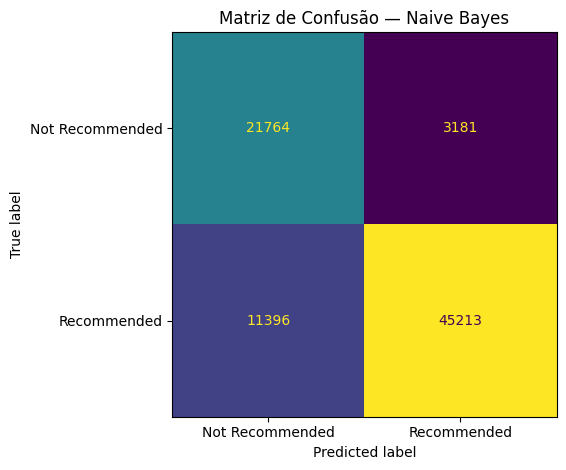


Tabela Comparativa — Naive Bayes vs. Regressão Logística (3VA):


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
Regressão Logística (3VA),0.8543,0.9281,0.8564,0.8908
Naive Bayes,0.8213,0.9343,0.7987,0.8612



Calculando SHAP values — Naive Bayes...
✓ Concluído.


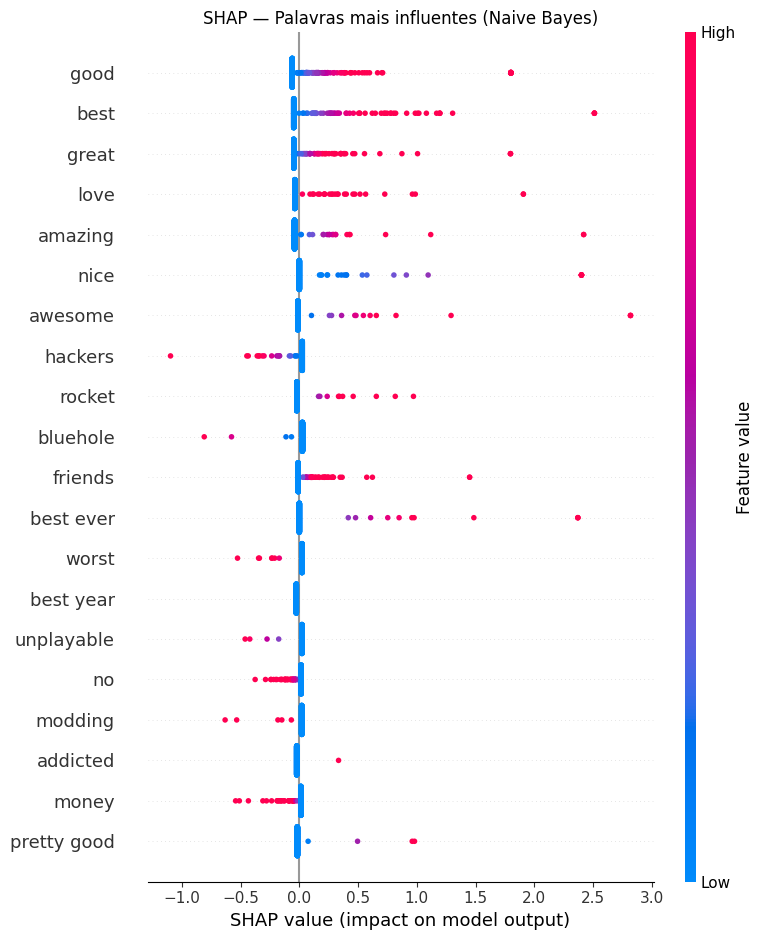

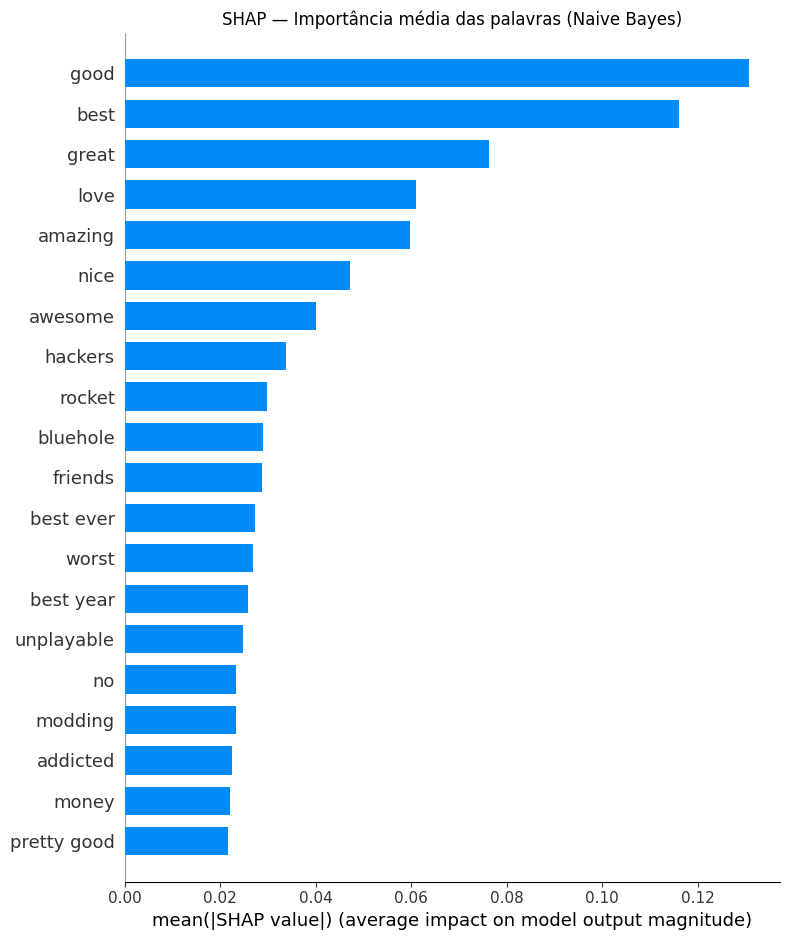


✓ Pipeline individual (Igor Dias) concluído.


In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import shap
import numpy as np

# ============================================================
# Contribuição individual — Igor Dias
# Modelo novo: Naive Bayes (MultinomialNB)
# Target: recommendation (1 = Recommended, 0 = Not Recommended)
# Reaproveita X_train_100k, y_train_100k, X_test, y_test, tfidf
# já preparados nas células anteriores
# ============================================================

print("Treinando: Naive Bayes (MultinomialNB)...")
nb_model = MultinomialNB()
nb_model.fit(X_train_100k, y_train_100k)
modelos_treinados["Naive Bayes"] = nb_model
print("  ✓ Concluído.")

# --- Avaliação ---
y_pred_nb = nb_model.predict(X_test)

metrics_nb = {
    "Modelo": "Naive Bayes",
    "Acurácia": accuracy_score(y_test, y_pred_nb),
    "Precisão": precision_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "F1-Score": f1_score(y_test, y_pred_nb),
}
print("\nMétricas — Naive Bayes:")
for k, v in metrics_nb.items():
    print(f"  {k}: {v}")

print("\nClassification Report — Naive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=["Not Recommended", "Recommended"]))

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=["Not Recommended", "Recommended"],
    ax=ax, colorbar=False
)
ax.set_title("Matriz de Confusão — Naive Bayes")
plt.tight_layout()
plt.savefig("confusion_matrix_Naive_Bayes.png", dpi=150)
plt.show()

# --- Tabela comparativa: Naive Bayes vs. melhor modelo da 3VA (Regressão Logística) ---
y_pred_lr = modelos_treinados["Regressão Logística"].predict(X_test)
comparativo = pd.DataFrame([
    {
        "Modelo": "Regressão Logística (3VA)",
        "Acurácia": accuracy_score(y_test, y_pred_lr),
        "Precisão": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1-Score": f1_score(y_test, y_pred_lr),
    },
    metrics_nb,
]).set_index("Modelo").round(4)

print("\nTabela Comparativa — Naive Bayes vs. Regressão Logística (3VA):")
display(comparativo)

# ============================================================
# XAI — SHAP para o Naive Bayes
# O score do MultinomialNB é LINEAR nos valores de TF-IDF:
# score(x) = x · (log P(w|Rec) - log P(w|NãoRec)) + intercepto
# Por isso usamos shap.LinearExplainer, a mesma técnica do
# artigo original (usada para a Regressão Logística).
# ============================================================

coef_nb = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]
intercept_nb = nb_model.class_log_prior_[1] - nb_model.class_log_prior_[0]

feature_names = tfidf.get_feature_names_out()
X_shap_nb = X_test[:500]

print("\nCalculando SHAP values — Naive Bayes...")
explainer_nb = shap.LinearExplainer((coef_nb, intercept_nb), X_train_100k[:500])
shap_values_nb = explainer_nb.shap_values(X_shap_nb)
print("✓ Concluído.")

X_shap_nb_dense = X_shap_nb.toarray() if hasattr(X_shap_nb, 'toarray') else X_shap_nb

plt.figure()
shap.summary_plot(shap_values_nb, X_shap_nb_dense, feature_names=feature_names, show=False)
plt.title("SHAP — Palavras mais influentes (Naive Bayes)")
plt.tight_layout()
plt.savefig("shap_summary_naive_bayes.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
shap.summary_plot(shap_values_nb, X_shap_nb_dense, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP — Importância média das palavras (Naive Bayes)")
plt.tight_layout()
plt.savefig("shap_bar_naive_bayes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ Pipeline individual (Igor Dias) concluído.")

---
## 16. EDA Textual

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. Proporção Recommended vs Not Recommended (antes do balanceamento) ──
contagem = df_reviews['recommendation'].value_counts()
plt.figure(figsize=(6, 4))
contagem.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Proporção de Reviews por Classe (antes do balanceamento)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_proporcao_classes.png', dpi=150)
plt.show()
print(contagem)
print(f"\nProporção: {(contagem / contagem.sum() * 100).round(1).to_dict()}")

# ── 2. Distribuição do tamanho das reviews por classe ──
df_reviews['tamanho_review'] = df_reviews['review'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, classe in zip(axes, ['Recommended', 'Not Recommended']):
    dados = df_reviews[df_reviews['recommendation'] == classe]['tamanho_review']
    ax.hist(dados, bins=50, color='#2ecc71' if classe == 'Recommended' else '#e74c3c', alpha=0.7)
    ax.set_title(f'Tamanho das Reviews — {classe}')
    ax.set_xlabel('Número de caracteres')
    ax.set_ylabel('Frequência')
    ax.set_xlim(0, 2000)

plt.tight_layout()
plt.savefig('eda_tamanho_reviews.png', dpi=150)
plt.show()

---
## 16. Clusterização com KMeans (PP1)

Segmentação não supervisionada dos jogos por perfil de engajamento e retorno.

In [ ]:
# Bibliotecas de clusterização já importadas na célula de configuração.
print("✓ KMeans, PCA e silhouette_score disponíveis.")

In [ ]:
# Base e Features para Clusterização

# Features selecionadas para o KMeans
FEATURES_CLUSTER = ['avg_hours', 'positive_ratio', 'est_revenue_proxy', 'discount']

# Criação da base de clusterização a partir dos dados reais tratados
# (df_pipeline já removeu nulos das principais features no pipeline supervisionado)
df_cluster = df_pipeline[FEATURES_CLUSTER + ['title', 'app_id']].dropna().copy()

print(f"Base para clusterização: {df_cluster.shape[0]} jogos | {len(FEATURES_CLUSTER)} features")
print(f"\nFeatures selecionadas: {FEATURES_CLUSTER}")
print(f"\nEstatísticas descritivas:")
display(df_cluster[FEATURES_CLUSTER].describe())

In [ ]:
# Transformação Logarítmica e Normalização
# avg_hours e est_revenue_proxy têm distribuição muito assimétrica (skewed),
# com valores extremos que distorceriam as distâncias euclidianas do KMeans.
# Aplicamos np.log1p (log(1 + x)) para estabilizar a escala.

df_cluster['log_avg_hours']        = np.log1p(df_cluster['avg_hours'])
df_cluster['log_est_revenue_proxy'] = np.log1p(df_cluster['est_revenue_proxy'])

# Features finais para o KMeans (versões transformadas onde necessário)
FEATURES_KMEANS = ['log_avg_hours', 'positive_ratio', 'log_est_revenue_proxy', 'discount']

# StandardScaler nas features finais (Z-score)
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster[FEATURES_KMEANS])

print("✓ Transformação logarítmica aplicada em: avg_hours, est_revenue_proxy")
print("✓ StandardScaler aplicado nas 4 features finais")
print(f"\nFeatures usadas no KMeans: {FEATURES_KMEANS}")
print(f"Shape da matriz de entrada: {X_cluster.shape}")

In [ ]:
# Escolha do K — Cotovelo e Silhouette

k_range    = range(2, 9)
inertias   = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))
    print(f"  K={k} | Inertia: {km.inertia_:,.0f} | Silhouette: {silhouettes[-1]:.4f}")

# ── Gráfico do Cotovelo ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title("Método do Cotovelo\nInertia por Número de Clusters", fontsize=12, pad=10)
axes[0].set_xlabel("Número de Clusters (K)", fontsize=11)
axes[0].set_ylabel("Inertia (Soma de Quadrados Intra-Cluster)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(list(k_range))

# ── Gráfico de Silhouette ────────────────────────────────────
axes[1].plot(list(k_range), silhouettes, marker='s', color='darkorange', linewidth=2, markersize=7)
axes[1].set_title("Silhouette Score por K\n(mais alto = clusters mais coesos e separados)", fontsize=12, pad=10)
axes[1].set_xlabel("Número de Clusters (K)", fontsize=11)
axes[1].set_ylabel("Silhouette Score Médio", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(list(k_range))

plt.suptitle("Seleção do Número de Clusters — KMeans | Steam Games", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvo: kmeans_elbow_silhouette.png")

In [ ]:
# KMeans Final
# O K final é escolhido com base nos gráficos acima:
#   - Cotovelo: ponto onde a inertia deixa de cair abruptamente.
#   - Silhouette: K com o maior score médio.
# Se não houver um ponto de corte claro, usamos K=4 como padrão
# interpretável (baixo, médio, alto engajamento + nicho).
# Ajuste K_FINAL conforme os gráficos observados na sua execução.

K_FINAL = 4  # ← ajuste aqui se os gráficos indicarem outro K

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_cluster)

# Distribuição dos clusters
contagem = df_cluster['cluster'].value_counts().sort_index()
print(f"✓ KMeans executado com K={K_FINAL}")
print(f"\nDistribuição de jogos por cluster:")
for cl, cnt in contagem.items():
    print(f"  Cluster {cl}: {cnt:,} jogos ({cnt/len(df_cluster)*100:.1f}%)")

In [ ]:
# Visualização PCA 2D dos Clusters

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]

var_exp = pca.explained_variance_ratio_
print(f"Variância explicada — PC1: {var_exp[0]:.1%} | PC2: {var_exp[1]:.1%} | Total: {sum(var_exp):.1%}")

# Scatter colorido por cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10.colors

for cl in sorted(df_cluster['cluster'].unique()):
    mask = df_cluster['cluster'] == cl
    ax.scatter(
        df_cluster.loc[mask, 'pca1'],
        df_cluster.loc[mask, 'pca2'],
        s=10, alpha=0.5, color=colors[cl], label=f"Cluster {cl}"
    )

ax.set_title(
    f"Visualização dos Clusters — KMeans (K={K_FINAL}) | Redução PCA 2D\n"
    f"Variância explicada: PC1={var_exp[0]:.1%}, PC2={var_exp[1]:.1%}",
    fontsize=12, pad=12
)
ax.set_xlabel("PC1", fontsize=11)
ax.set_ylabel("PC2", fontsize=11)
ax.legend(title="Cluster", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("kmeans_pca2d.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvo: kmeans_pca2d.png")

In [ ]:
# Perfil dos Clusters — Médias e Exemplos

# ── Tabela de perfil (médias nas features originais) ────────
perfil_cols = ['avg_hours', 'positive_ratio', 'est_revenue_proxy', 'discount']
df_perfil = df_cluster.groupby('cluster')[perfil_cols].agg(['mean', 'median']).round(2)
df_perfil.columns = ['_'.join(c) for c in df_perfil.columns]
df_perfil['n_jogos'] = df_cluster.groupby('cluster')['cluster'].count()

print("=== Perfil Médio dos Clusters (features originais, sem transformação) ===\n")
display(df_perfil)

# ── Exemplos de jogos por cluster ────────────────────────────
print("\n=== Exemplos de jogos por cluster (top 5 por est_revenue_proxy) ===\n")
for cl in sorted(df_cluster['cluster'].unique()):
    subset = (df_cluster[df_cluster['cluster'] == cl]
              .sort_values('est_revenue_proxy', ascending=False)
              .head(5)[['title', 'avg_hours', 'positive_ratio', 'est_revenue_proxy']])
    print(f"── Cluster {cl} ──")
    display(subset)

# ── Tags mais frequentes por cluster (se df_tags estiver disponível) ─
try:
    df_cluster_tags = df_cluster[['app_id', 'cluster']].merge(df_tags, on='app_id', how='inner')
    print("\n=== Top 5 Tags por Cluster ===\n")
    for cl in sorted(df_cluster_tags['cluster'].unique()):
        top_tags = (df_cluster_tags[df_cluster_tags['cluster'] == cl]['tag']
                    .value_counts().head(5))
        print(f"Cluster {cl}: {', '.join(top_tags.index.tolist())}")
except Exception:
    print("\n(df_tags não disponível nesta sessão — reinicie e execute o Bloco 7 antes.)")

In [ ]:
# Nomes Interpretativos dos Clusters
# Os nomes abaixo são SUGESTÕES baseadas nos valores da tabela de perfil.
# Revise e ajuste conforme os valores reais gerados na sua execução.

# Ordena os clusters por est_revenue_proxy mediana para nomear de forma consistente
rank_revenue = df_perfil['est_revenue_proxy_median'].sort_values()

nomes_cluster = {}
for rank, cl in enumerate(rank_revenue.index):
    avg_h   = df_perfil.loc[cl, 'avg_hours_median']
    pos_r   = df_perfil.loc[cl, 'positive_ratio_median']
    rev     = df_perfil.loc[cl, 'est_revenue_proxy_median']
    disc    = df_perfil.loc[cl, 'discount_mean']

    if rev < rank_revenue.quantile(0.25):
        nome = "Baixo Engajamento e Baixo Retorno"
    elif rev < rank_revenue.quantile(0.50):
        nome = "Engajamento Moderado e Retorno Intermediário"
    elif pos_r >= rank_revenue.quantile(0.75) or avg_h >= df_perfil['avg_hours_median'].quantile(0.75):
        nome = "Alta Aprovação e Alto Engajamento"
    else:
        nome = "Alto Faturamento Estimado"

    nomes_cluster[cl] = nome
    print(f"Cluster {cl} → \"{nome}\"")
    print(f"   Mediana horas: {avg_h:.1f}h | Aprovação: {pos_r:.1f}% | Revenue proxy: {rev:,.0f} | Desconto médio: {disc:.1f}%\n")

# Adiciona nome ao df_cluster
df_cluster['cluster_nome'] = df_cluster['cluster'].map(nomes_cluster)

In [ ]:
# Salvamento — Artefatos de Clusterização

# Base completa com cluster
df_cluster.to_csv("steam_games_clusters.csv", index=False)
print("✓ Salvo: steam_games_clusters.csv")

# Tabela de perfil dos clusters
df_perfil.to_csv("kmeans_cluster_perfil.csv")
print("✓ Salvo: kmeans_cluster_perfil.csv")

# Resumo de silhouette scores
df_silhouette = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertias,
    'Silhouette_Score': silhouettes
})
df_silhouette.to_csv("kmeans_silhouette_scores.csv", index=False)
print("✓ Salvo: kmeans_silhouette_scores.csv")

print("\nArquivos gerados nesta etapa de clusterização:")
for arq in ["steam_games_clusters.csv", "kmeans_cluster_perfil.csv",
            "kmeans_silhouette_scores.csv", "kmeans_elbow_silhouette.png", "kmeans_pca2d.png"]:
    print(f"  • {arq}")

In [ ]:
# Síntese — KMeans e PP1

sil_k4 = silhouettes[list(k_range).index(K_FINAL)] if K_FINAL in k_range else "N/D"
melhor_k  = list(k_range)[silhouettes.index(max(silhouettes))]
melhor_sil = max(silhouettes)

print("=" * 65)
print("   SÍNTESE — CLUSTERIZAÇÃO KMEANS | PP1")
print("   Pergunta: Padrões de Sucesso Comercial na Steam")
print("=" * 65)
print(f"""
A) FEATURES USADAS NO KMEANS:
   → log_avg_hours (np.log1p de avg_hours)
   → positive_ratio (sem transformação)
   → log_est_revenue_proxy (np.log1p de est_revenue_proxy)
   → discount (sem transformação)
   Todas normalizadas com StandardScaler antes do KMeans.

B) K ESCOLHIDO E JUSTIFICATIVA:
   → K={K_FINAL} (ajuste conforme gráficos)
   O K foi selecionado observando o cotovelo da inertia (ponto
   onde a curva deixa de cair abruptamente) e o pico do
   Silhouette Score. K=4 é um bom equilíbrio entre granularidade
   e interpretabilidade para o artigo.

C) SILHOUETTE SCORES POR K:""")

for k, sil in zip(k_range, silhouettes):
    marcador = " ← K escolhido" if k == K_FINAL else (" ← melhor" if k == melhor_k and k != K_FINAL else "")
    print(f"   K={k}: {sil:.4f}{marcador}")

print(f"""
D) INTERPRETAÇÃO DOS CLUSTERS:""")
for cl, nome in nomes_cluster.items():
    print(f"   Cluster {cl}: {nome}")
    print(f"     Mediana horas: {df_perfil.loc[cl,'avg_hours_median']:.1f}h | "
          f"Aprovação: {df_perfil.loc[cl,'positive_ratio_median']:.1f}% | "
          f"Revenue proxy: {df_perfil.loc[cl,'est_revenue_proxy_median']:,.0f}")

print(f"""
E) CLUSTERS ASSOCIADOS A SUCESSO COMERCIAL:
   → Os clusters com maior mediana de est_revenue_proxy e
     positive_ratio são os mais associados a sucesso comercial.
   → Revise a tabela de perfil para identificar o(s) cluster(s)
     que combinam alto faturamento estimado com boa aprovação.

F) CUIDADOS METODOLÓGICOS:
   1. est_revenue_proxy = price_final × user_reviews é uma
      estimativa rudimentar (método Boxleiter simplificado),
      não faturamento real. Deve ser tratada como indicador
      relativo, não valor absoluto.
   2. KMeans assume clusters esféricos e é sensível a outliers.
      A transformação log1p e o StandardScaler mitigam isso.
   3. A clusterização é não supervisionada: não usa commercial_success
      como label, o que garante independência metodológica.
   4. Silhouette Score abaixo de 0,30 indica sobreposição relevante
      entre clusters — mencionar no artigo se for o caso.

G) FIGURAS E TABELAS PARA O ARTIGO:
   • kmeans_elbow_silhouette.png → justifica escolha do K
   • kmeans_pca2d.png            → visualização dos clusters
   • kmeans_cluster_perfil.csv  → tabela de perfil por cluster
   • steam_games_clusters.csv   → base completa para análises futuras

H) A PP1 JÁ PODE SER DISCUTIDA?
   → Sim. Com os clusters gerados, é possível identificar e
     descrever perfis distintos de jogos na Steam com base em
     engajamento, aprovação, desconto e faturamento estimado.
   → A PP1 é complementar à PP2 (classificação supervisionada):
     enquanto o SHAP responde "quais features predizem sucesso",
     o KMeans responde "quais grupos naturais existem no mercado".
   → Recomenda-se cruzar os clusters com os resultados SHAP:
     jogos do cluster de "Alto Faturamento" devem concentrar
     os casos onde avg_hours e positive_ratio são mais altos.
""")
print("=" * 65)
print("✓ Síntese PP1 concluída. Material pronto para o artigo.")
print("=" * 65)